In [12]:
import pandas as pd
import os

# Check current folder
print("Current Directory:", os.getcwd())
print("Files Here:", os.listdir())

train_path = "archive (1).zip"

Current Directory: c:\Users\HP\OneDrive\Desktop\Movie Genre Classification\movie-genre-classification\notebooks
Files Here: ['01_eda.ipynb', '02_baseline_model.ipynb', '03_bert_experiments.ipynb']


In [14]:
import os
print("Current Folder:", os.getcwd())
print("Files in this folder:", os.listdir())

Current Folder: c:\Users\HP\OneDrive\Desktop\Movie Genre Classification\movie-genre-classification\notebooks
Files in this folder: ['01_eda.ipynb', '02_baseline_model.ipynb', '03_bert_experiments.ipynb']


In [15]:
train_path = "../data/raw/Genre Classification Dataset/train_data.txt"

import pandas as pd

df = pd.read_csv(train_path, sep=" ::: ", engine="python", header=None)
df.columns = ["id", "title", "genre", "plot"]

df.head()

,id,title,genre,plot
0,1,Oscar et la dame rose (2009),drama,Listening in to a conversation between his doc...
1,2,Cupid (1997),thriller,A brother and sister with a past incestuous re...
2,3,"Young, Wild and Wonderful (1980)",adult,As the bus empties the students for their fiel...
3,4,The Secret Sin (1915),drama,To help their unemployed father make ends meet...
4,5,The Unrecovered (2007),drama,The film's title refers not only to the un-rec...


In [16]:
df.shape

(54214, 4)

In [17]:
df['genre'].value_counts().head()

genre
drama          13613
documentary    13096
comedy          7447
short           5073
horror          2204
Name: count, dtype: int64

In [18]:
df['genre'].nunique()

27

In [19]:
sorted(df['genre'].unique())

['action',
 'adult',
 'adventure',
 'animation',
 'biography',
 'comedy',
 'crime',
 'documentary',
 'drama',
 'family',
 'fantasy',
 'game-show',
 'history',
 'horror',
 'music',
 'musical',
 'mystery',
 'news',
 'reality-tv',
 'romance',
 'sci-fi',
 'short',
 'sport',
 'talk-show',
 'thriller',
 'war',
 'western']

In [20]:
df.isnull().sum()

id       0
title    0
genre    0
plot     0
dtype: int64

In [21]:
df['plot_length'] = df['plot'].apply(lambda x: len(str(x).split()))

df['plot_length'].describe()

count    54214.000000
mean       101.907386
std         76.579192
min          6.000000
25%         55.000000
50%         79.000000
75%        121.000000
max       1829.000000
Name: plot_length, dtype: float64

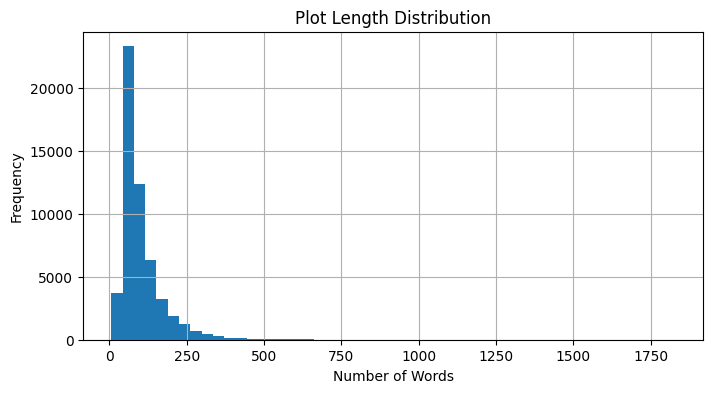

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
df['plot_length'].hist(bins=50)
plt.title("Plot Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

In [23]:
df['genre'].nunique()

27

In [24]:
df.isnull().sum()

id             0
title          0
genre          0
plot           0
plot_length    0
dtype: int64

In [26]:
df.duplicated().sum()

np.int64(0)

In [27]:
df['genre'].value_counts(normalize=True).head()

genre
drama          0.251098
documentary    0.241561
comedy         0.137363
short          0.093574
horror         0.040654
Name: proportion, dtype: float64

In [28]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...


True